In [1]:
!pip install nltk

In [3]:
!pip install contractions

^C


In [40]:
nltk.data.path.append(r'C:\Users\nb178057\nltk_data\tokenizers')

In [42]:

import nltk

# Print current NLTK data paths
print(nltk.data.path)


['C:\\Users\\nb178057/nltk_data', 'C:\\ProgramData\\anaconda3\\nltk_data', 'C:\\ProgramData\\anaconda3\\share\\nltk_data', 'C:\\ProgramData\\anaconda3\\lib\\nltk_data', 'C:\\Users\\nb178057\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data', 'C:\\Users\\nb178057\\nltk_data', 'C:\\Users\\nb178057\\nltk_data', 'C:\\Users\\nb178057\\nltk_data\\tokenizers', 'C:\\Users\\nb178057\\nltk_data\\tokenizers']


In [34]:
 import pandas as pd
 import numpy as np
 import re
 import string
 from sklearn.model_selection import train_test_split
 from sklearn.preprocessing import LabelEncoder
 from sklearn.feature_extraction.text import CountVectorizer
 from nltk.corpus import stopwords
 from nltk.stem import WordNetLemmatizer
 import nltk
 from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
 from bs4 import BeautifulSoup

In [38]:
stop_words = set(stopwords.words('english'))
synsets = wordnet.synsets('example')

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - 'C:\\Users\\nb178057/nltk_data'
    - 'C:\\ProgramData\\anaconda3\\nltk_data'
    - 'C:\\ProgramData\\anaconda3\\share\\nltk_data'
    - 'C:\\ProgramData\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\nb178057\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
    - 'C:\\Users\\nb178057\\nltk_data'
    - 'C:\\Users\\nb178057\\nltk_data'
    - 'C:\\Users\\nb178057\\nltk_data\\tokenizers'
**********************************************************************


In [4]:
# Load data
df_train = pd.read_csv('train.csv')
df_test= pd.read_csv('test.csv')

In [9]:
print(df_train.columns.tolist())

['headlines', 'description', 'content', 'url', 'category', 'full_text']


In [20]:
# Initialize tools
stop_words = ENGLISH_STOP_WORDS
lemmatizer = WordNetLemmatizer()

In [7]:
# Combine text fields
df_train['full_text'] = df_train['headlines'].fillna('') + ' ' + df_train['description'].fillna('') + ' ' + df_train['content'].fillna('')
df_test['full_text'] = df_test['headlines'].fillna('') + ' ' + df_test['description'].fillna('') + ' ' + df_test['content'].fillna('')

In [16]:
 def clean_text(text):
     text = contractions.fix(text)  # expand contractions
     text = text.lower()
     text = re.sub(r"http\S+", "", text)  # remove URLs
     text = BeautifulSoup(text, "html.parser").get_text()  # remove HTML tags
     text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
     text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
     text = re.sub(r'\d+', '', text)  # remove numbers
     tokens = text.split()
     tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word.isalpha()]
     return ' '.join(tokens)

 df_train['processed_text'] = df_train['full_text'].apply(clean_text)
 df_test['processed_text'] = df_test['full_text'].apply(clean_text)

LookupError: 
**********************************************************************
  Resource [93mwordnet[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('wordnet')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/wordnet[0m

  Searched in:
    - '/home/jovyan/nltk_data'
    - '/opt/conda/nltk_data'
    - '/opt/conda/share/nltk_data'
    - '/opt/conda/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [17]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

NameError: name 'df' is not defined

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [16]:
# Vectorize text using CountVectorizer with unigrams and bigrams
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Create model

In [17]:
from sklearn.linear_model import LogisticRegression

# Create the model with optional parameters
model = LogisticRegression(max_iter=1000, solver='liblinear')  # 'liblinear' is good for small datasets


In [18]:
model.fit(X_train_vec, y_train)

C:\Users\Katy Sonnekus\anaconda3\envs\NLP\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test_vec)


Evaluate model

In [20]:
from sklearn.metrics import classification_report, accuracy_score

# Print accuracy and classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9628623188405797

Classification Report:
                precision    recall  f1-score   support

     business       0.95      0.93      0.94       224
    education       0.99      0.99      0.99       304
entertainment       0.98      0.95      0.97       192
       sports       0.95      0.96      0.95       128
   technology       0.93      0.96      0.95       256

     accuracy                           0.96      1104
    macro avg       0.96      0.96      0.96      1104
 weighted avg       0.96      0.96      0.96      1104



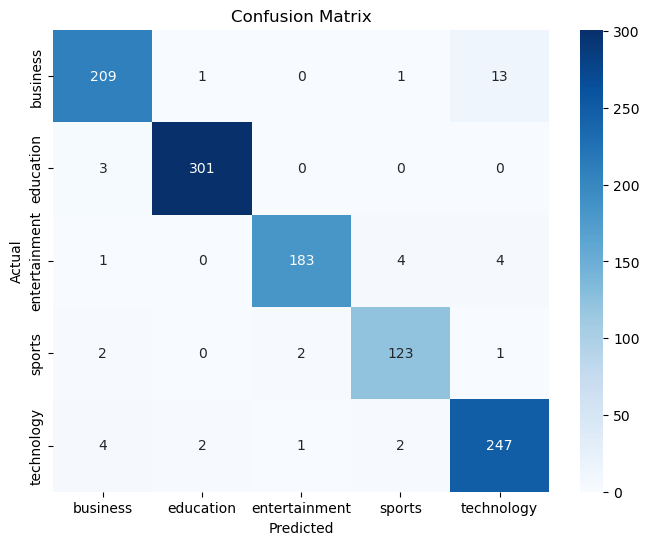

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

# Generate predictions
y_pred = model.predict(X_test_vec)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

# Plot it
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


get model coefficients

In [26]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_

# Example: top words for each category
for i, category in enumerate(label_encoder.classes_):
    top_indices = np.argsort(coefficients[i])[-10:]
    print(f"\nTop features for '{category}':")
    print([feature_names[idx] for idx in top_indices])



Top features for 'business':
['said', 'loan', 'crore', 'oil', 'gst', 'trade', 'economy', 'govt', 'rbi', 'bank']

Top features for 'education':
['ignou', 'candidate', 'neet', 'school', 'programme', 'university', 'education', 'exam', 'student', 'iit']

Top features for 'entertainment':
['vijayakanth', 'trailer', 'star', 'shared', 'singer', 'opened', 'khan', 'movie', 'actor', 'film']

Top features for 'sports':
['bat', 'league', 'open', 'match', 'pakistan', 'club', 'coach', 'player', 'england', 'champion']

Top features for 'technology':
['iphone', 'tech', 'whatsapp', 'nasa', 'scientist', 'user', 'google', 'ai', 'openai', 'apple']


streamlit

In [ ]:
# app.py
import streamlit as st
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pickle

# NLTK downloads
nltk.download('stopwords')
nltk.download('wordnet')

# Preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word.isalpha()]
    return " ".join(tokens)

# Load trained model and vectorizer (assumes you saved them earlier)
model = pickle.load(open('model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))
label_encoder = pickle.load(open('label_encoder.pkl', 'rb'))

# Streamlit UI
st.title("📰 News Category Classifier")
user_input = st.text_area("Enter a news headline or short article:")

if st.button("Classify"):
    if user_input.strip() == "":
        st.warning("Please enter some text.")
    else:
        cleaned = clean_text(user_input)
        vec = vectorizer.transform([cleaned])
        pred = model.predict(vec)
        category = label_encoder.inverse_transform(pred)[0]
        st.success(f"Predicted Category: **{category}**")


In [ ]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))
pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))


In [ ]:
streamlit run app.py
